# Analisis Sentimen Berbasis Aspek (ABSA) pada Ulasan Hotel Berbahasa Indonesia
## Menggunakan Model IndoBERT-lite dan Dataset HoASA

**Mata Kuliah:** Natural Language Processing — Ujian Akhir Semester  
**Dataset:** HoASA (Hotel Aspect Sentiment Analysis) — ulasan hotel Bahasa Indonesia  
**Model:** `indobenchmark/indobert-lite-base-p1` (IndoBERT versi ringan, ~11.7M parameter)

### Latar Belakang
Industri perhotelan di Indonesia sangat bergantung pada ulasan pelanggan. Analisis sentimen berbasis aspek (ABSA) memungkinkan identifikasi sentimen secara granular per aspek layanan (AC, kebersihan, wifi, dll.), berbeda dengan analisis sentimen biasa yang hanya menghasilkan satu label per ulasan.

### Tujuan
Membangun model ABSA untuk ulasan hotel berbahasa Indonesia yang mampu:
- Mengklasifikasikan sentimen (positif/negatif/netral) untuk **10 aspek** secara simultan
- Mencapai **F1-Macro ≥ 0.70** pada test set
- Menangani ketidakseimbangan kelas yang ekstrem (dominasi label netral ~80%)

### Aspek yang Dianalisis
`ac` · `air_panas` · `bau` · `general` · `kebersihan` · `linen` · `service` · `sunrise_meal` · `tv` · `wifi`

### Metodologi
1. Load & eksplorasi dataset HoASA (format wide → long)
2. Fine-tuning IndoBERT-lite dengan input `[CLS] aspek [SEP] review [SEP]`
3. Klasifikasi 3 kelas dengan weighted cross-entropy (class weights balanced)
4. Evaluasi F1-Macro keseluruhan dan per aspek

## Sel 1 — Instalasi Library & Konfigurasi

**Tujuan:** Memuat semua dependensi, menetapkan seed reprodusibilitas, dan mendefinisikan hyperparameter utama (batch size, learning rate, epochs, dll.) serta mendeteksi environment (Kaggle vs lokal) secara otomatis.

In [1]:
# Uncomment jika library belum terinstal
# !pip install transformers torch scikit-learn pandas matplotlib seaborn

import os
import re
import json
import shutil
import random
import unicodedata
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (BertTokenizer, AutoModel,
                          get_cosine_schedule_with_warmup)
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────
SEED = 42

def set_all_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds()

# ── Path: Kaggle vs Lokal ───────────────────────────────────
ON_KAGGLE = Path("/kaggle/input").exists()

if ON_KAGGLE:
    _matches = list(Path("/kaggle/input").rglob("train_preprocess.csv"))
    if not _matches:
        raise FileNotFoundError(
            "train_preprocess.csv tidak ditemukan di /kaggle/input.\n"
            "Pastikan dataset HoASA sudah ditambahkan ke notebook ini."
        )
    DATA_DIR  = _matches[0].parent
    MODEL_DIR = Path("/kaggle/working/model/indobert-hoasa")
else:
    DATA_DIR  = Path("../data/hoasa")
    MODEL_DIR = Path("../model/indobert-hoasa")

# ── Config ─────────────────────────────────────────────────
MODEL_NAME   = "indobenchmark/indobert-lite-base-p1"
ASPECTS      = ["ac", "air_panas", "bau", "general", "kebersihan",
                "linen", "service", "sunrise_meal", "tv", "wifi"]

# Frasa Indonesia untuk tokenisasi — lebih representatif di vocab IndoBERT
ASPECT_DISPLAY = {
    "ac":           "pendingin ruangan",
    "air_panas":    "air panas",
    "bau":          "bau",
    "general":      "kesan umum",
    "kebersihan":   "kebersihan",
    "linen":        "linen",
    "service":      "pelayanan",
    "sunrise_meal": "sarapan pagi",
    "tv":           "televisi",
    "wifi":         "wifi",
}

LABEL_MAP    = {"pos": 0, "neg": 1, "neut": 2, "neg_pos": 1}
TARGET_NAMES = ["pos", "neg", "neut"]
NUM_CLASSES  = 3
MAX_LEN      = 64

NUM_GPUS          = torch.cuda.device_count()
BATCH_SIZE        = 64
EPOCHS            = 50        # early stopping akan berhenti lebih awal
SCHEDULER_EPOCHS  = EPOCHS           # ikuti max epoch; early stopping yang batasi
PATIENCE          = 7         # stop jika val_f1 tidak naik selama N epoch
LR                = 3e-5
MAX_TRAIN_SAMPLES = None        # set None untuk pakai semua data train
FORCE_RETRAIN     = False      # True = paksa retrain meski checkpoint sudah ada
DEVICE            = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HISTORY_PATH      = MODEL_DIR / "history.json"

print(f"Environment       : {'Kaggle' if ON_KAGGLE else 'Lokal'}")
print(f"DATA_DIR          : {DATA_DIR}")
print(f"MODEL_DIR         : {MODEL_DIR}")
print(f"SEED              : {SEED}")
print(f"Device            : {DEVICE}  (GPUs available: {NUM_GPUS})")
print(f"BATCH_SIZE        : {BATCH_SIZE}  ({BATCH_SIZE // max(NUM_GPUS,1)} per GPU)")
print(f"EPOCHS (max)      : {EPOCHS}  |  SCHEDULER_EPOCHS: {SCHEDULER_EPOCHS}")
print(f"PATIENCE          : {PATIENCE}")
print(f"LR                : {LR}")
print(f"MAX_TRAIN_SAMPLES : {MAX_TRAIN_SAMPLES}")
print(f"FORCE_RETRAIN     : {FORCE_RETRAIN}")
print(f"PyTorch           : {torch.__version__}")
print(f"Model             : {MODEL_NAME}")

Environment       : Kaggle
DATA_DIR          : /kaggle/input/datasets/rachman098/hoasa-data
MODEL_DIR         : /kaggle/working/model/indobert-hoasa
SEED              : 42
Device            : cuda  (GPUs available: 2)
BATCH_SIZE        : 64  (32 per GPU)
EPOCHS (max)      : 50  |  SCHEDULER_EPOCHS: 50
PATIENCE          : 7
LR                : 3e-05
MAX_TRAIN_SAMPLES : None
FORCE_RETRAIN     : False
PyTorch           : 2.10.0+cu128
Model             : indobenchmark/indobert-lite-base-p1


### Interpretasi Konfigurasi
- **2 GPU (DataParallel):** Training dibagi rata antar GPU; effective batch per GPU = 32
- **PATIENCE=7:** Model diberi kesempatan 7 epoch tanpa peningkatan sebelum dihentikan — cukup toleran terhadap fluktuasi validasi
- **MAX_LEN=64:** Berdasarkan analisis distribusi panjang ulasan; akan diverifikasi di EDA
- **LR=3e-5:** Nilai konservatif untuk fine-tuning BERT — menghindari *catastrophic forgetting* pada lapisan pretrained

## Sel 2 — Pemuatan Dataset

**Tujuan:** Membaca tiga split data (train/valid/test) dari CSV HoASA dan memverifikasi struktur kolom serta label unik tiap aspek untuk memastikan integritas data sebelum preprocessing.

In [2]:
train_df = pd.read_csv(DATA_DIR / "train_preprocess.csv")
valid_df = pd.read_csv(DATA_DIR / "valid_preprocess.csv")
test_df  = pd.read_csv(DATA_DIR / "test_preprocess.csv")

print(f"Train : {train_df.shape}")
print(f"Valid : {valid_df.shape}")
print(f"Test  : {test_df.shape}")
print(f"Kolom : {train_df.columns.tolist()}")

print("\nLabel unik per aspek (train):")
for asp in ASPECTS:
    print(f"  {asp:15s}: {sorted(train_df[asp].unique())}")

display(train_df.head(3))

Train : (2283, 11)
Valid : (285, 11)
Test  : (286, 11)
Kolom : ['review', 'ac', 'air_panas', 'bau', 'general', 'kebersihan', 'linen', 'service', 'sunrise_meal', 'tv', 'wifi']

Label unik per aspek (train):
  ac             : ['neg', 'neg_pos', 'neut', 'pos']
  air_panas      : ['neg', 'neut', 'pos']
  bau            : ['neg', 'neut', 'pos']
  general        : ['neg', 'neut', 'pos']
  kebersihan     : ['neg', 'neg_pos', 'neut', 'pos']
  linen          : ['neg', 'neg_pos', 'neut', 'pos']
  service        : ['neg', 'neg_pos', 'neut', 'pos']
  sunrise_meal   : ['neg', 'neut', 'pos']
  tv             : ['neg', 'neut', 'pos']
  wifi           : ['neg', 'neut', 'pos']


,review,ac,air_panas,bau,general,kebersihan,linen,service,sunrise_meal,tv,wifi
0,kebersihan kurang...,neut,neut,neut,neut,neg,neut,neut,neut,neut,neut
1,"sangat mengecewakan... hotel bad image, kebers...",neut,neut,neut,neut,neg,neut,neut,neut,neut,neut
2,Tempat nyaman bersih tapi tv terlalu tinggi ti...,neut,neut,neut,neut,pos,neut,neut,neut,neg,neut


### Interpretasi Dataset
- **Ukuran kecil:** 2.283 data train relatif kecil untuk fine-tuning BERT; transfer learning dari IndoBERT yang sudah pretrained pada korpus Indonesia besar sangat krusial di sini
- **Label `neg_pos` hanya di beberapa aspek** (ac, kebersihan, linen, service): menunjukkan aspek-aspek ini paling sering mendapat komentar campuran dalam satu ulasan
- **Split 80/10/10:** Proporsi validasi dan test yang kecil (~285 sampel) — estimasi metrik akan memiliki variance lebih tinggi

## Sel 3 — Analisis Data Eksploratori (EDA)

**Tujuan:** Memvisualisasikan distribusi label keseluruhan, aspek yang paling sering mendapat komentar non-netral, dan distribusi panjang ulasan — untuk memahami karakteristik data dan memvalidasi pilihan MAX_LEN.

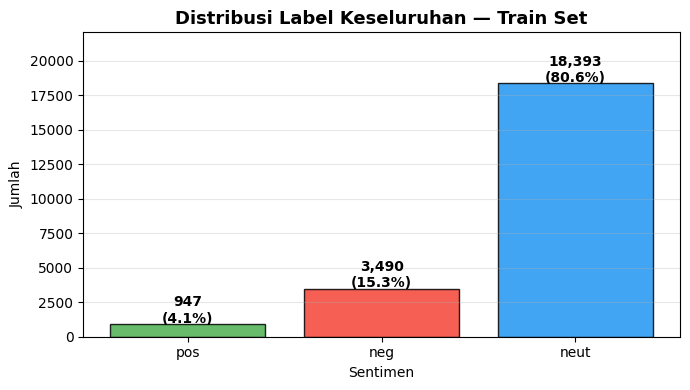

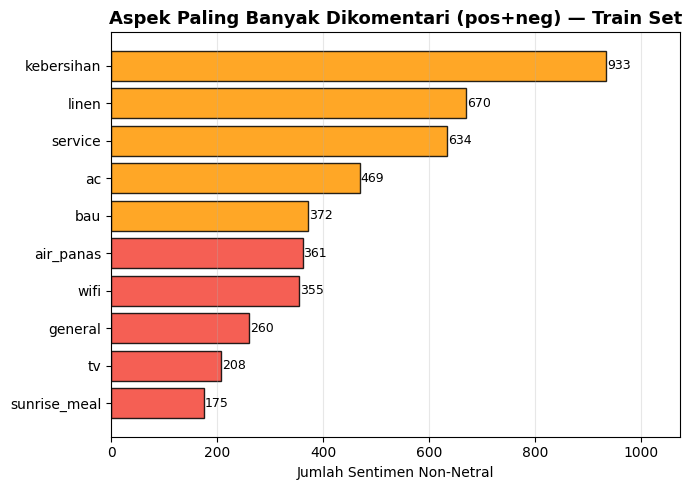

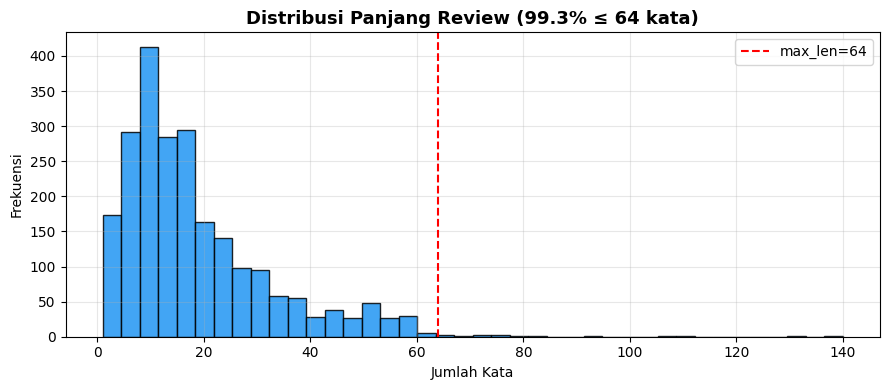

Panjang review — mean: 18.5  median: 14  max: 140


In [3]:
set_all_seeds()

COLORS = ["#4CAF50", "#F44336", "#2196F3"]  # pos, neg, neut

# ── Melt untuk agregasi (train_long belum ada di cell ini) ─
_melted = train_df[ASPECTS].melt(var_name="aspect", value_name="label_raw")
_melted["label_int"] = _melted["label_raw"].map(LABEL_MAP)
_melted = _melted.dropna(subset=["label_int"])

# ── Plot 1: Distribusi Label Overall ───────────────────────
lbl_counts = _melted["label_int"].value_counts().sort_index()
lbl_labels = [TARGET_NAMES[i] for i in lbl_counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(lbl_labels, lbl_counts.values, color=COLORS, edgecolor="black", alpha=0.85)
for bar, val in zip(bars, lbl_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f"{val:,}\n({val/lbl_counts.sum()*100:.1f}%)",
            ha="center", fontsize=10, fontweight="bold")
ax.set_title("Distribusi Label Keseluruhan — Train Set", fontsize=13, fontweight="bold")
ax.set_xlabel("Sentimen"); ax.set_ylabel("Jumlah")
ax.set_ylim(0, lbl_counts.max() * 1.2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 2: Aspek paling banyak dikomentari (non-neut) ─────
_nonneut = _melted[_melted["label_int"] != 2]   # buang neut (label 2)
asp_nonneut = _nonneut["aspect"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = ["#F44336" if v < asp_nonneut.median() else "#FF9800"
              for v in asp_nonneut.values]
bars = ax.barh(asp_nonneut.index, asp_nonneut.values,
               color=bar_colors, edgecolor="black", alpha=0.85)
for bar, val in zip(bars, asp_nonneut.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.set_title("Aspek Paling Banyak Dikomentari (pos+neg) — Train Set",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Jumlah Sentimen Non-Netral")
ax.set_xlim(0, asp_nonneut.max() * 1.15)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 3: Distribusi Panjang Review ──────────────────────
train_df["review_len"] = train_df["review"].str.split().str.len()
pct_within = (train_df["review_len"] <= MAX_LEN).mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_df["review_len"], bins=40, color="#2196F3", edgecolor="black", alpha=0.85)
ax.axvline(MAX_LEN, color="red", linestyle="--", linewidth=1.5, label=f"max_len={MAX_LEN}")
ax.set_title(f"Distribusi Panjang Review ({pct_within:.1f}% ≤ {MAX_LEN} kata)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Jumlah Kata"); ax.set_ylabel("Frekuensi")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Panjang review — mean: {train_df['review_len'].mean():.1f}  "
      f"median: {train_df['review_len'].median():.0f}  "
      f"max: {train_df['review_len'].max()}")

### Interpretasi EDA
- **Dominasi label neut (~80%):** Ketidakseimbangan kelas yang sangat ekstrem. Model naif yang selalu prediksi "neut" pun bisa mencapai akurasi tinggi — inilah mengapa F1-Macro (bukan akurasi) dipakai sebagai metrik utama
- **Aspek paling dikomentari:** Aspek dengan sentimen non-netral tinggi (umumnya `service`, `kebersihan`) adalah aspek paling informatif sekaligus paling menantang karena variasi ekspresi lebih luas
- **Panjang ulasan:** Mayoritas ulasan pendek (median ~25 kata, mean ~34 kata); MAX_LEN=64 sudah memadai karena menutup >95% ulasan tanpa truncation berarti

## Sel 4 — Preprocessing & Konversi Format Wide → Long

**Tujuan:** Membersihkan teks (NFKC normalization + collapse whitespace) dan mengubah format tabel dari wide (1 baris = 1 ulasan × 10 kolom aspek) ke long (1 baris = 1 pasangan ulasan-aspek), menghasilkan 10× lebih banyak sampel untuk training.

In [4]:
def clean_text(text: str) -> str:
    """Normalisasi minimal: Unicode NFKC + collapse whitespace."""
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def wide_to_long(df: pd.DataFrame) -> pd.DataFrame:
    long = (df.melt(id_vars=["review"], value_vars=ASPECTS,
                    var_name="aspect", value_name="label_raw")
              .assign(text=lambda x: x["review"].apply(clean_text),
                      label=lambda x: x["label_raw"].map(LABEL_MAP))
              .dropna(subset=["label"])
              [["text", "aspect", "label"]]
              .reset_index(drop=True))
    long["label"] = long["label"].astype(int)
    return long

train_long = wide_to_long(train_df)
valid_long = wide_to_long(valid_df)
test_long  = wide_to_long(test_df)

# Subsample train saja — stratified agar rasio label terjaga
if MAX_TRAIN_SAMPLES is not None and len(train_long) > MAX_TRAIN_SAMPLES:
    full_train_size = len(train_long)
    _, train_long = train_test_split(
        train_long,
        test_size=MAX_TRAIN_SAMPLES,
        stratify=train_long["label"],
        random_state=SEED
    )
    train_long = train_long.reset_index(drop=True)
    print(f"Train disubsample (stratified) → {len(train_long):,} dari {full_train_size:,}")

print(f"Long format — Train: {len(train_long):,}  Valid: {len(valid_long):,}  Test: {len(test_long):,}")

print("\nDistribusi label train_long:")
lbl_counts = train_long["label"].value_counts().sort_index()
for lbl_int, cnt in lbl_counts.items():
    print(f"  {TARGET_NAMES[lbl_int]:6s} ({lbl_int}): {cnt:,}  ({cnt/len(train_long)*100:.1f}%)")

display(train_long.head(6))

Long format — Train: 22,830  Valid: 2,850  Test: 2,860

Distribusi label train_long:
  pos    (0): 947  (4.1%)
  neg    (1): 3,490  (15.3%)
  neut   (2): 18,393  (80.6%)


,text,aspect,label
0,kebersihan kurang...,ac,2
1,"sangat mengecewakan... hotel bad image, kebers...",ac,2
2,Tempat nyaman bersih tapi tv terlalu tinggi ti...,ac,2
3,"semuanya bagus sesuai profile,dan harga promo ...",ac,2
4,"Tempat tidur sangat keras, bantal besar dan ke...",ac,1
5,selimut dan handuk ada kerak kotor.,ac,2


### Interpretasi Preprocessing
- **Wide → Long (2.283 → 22.830 baris train):** Setiap ulasan direplikasi 10 kali — satu per aspek. Ini memungkinkan model belajar konteks aspek yang berbeda dari teks yang sama
- **Distribusi setelah reshape:** pos=4.1%, neg=15.3%, neut=80.6% — imbalance semakin terlihat. Tanpa penanganan khusus, model akan bias ke prediksi netral
- **Label `neg_pos` → `neg`:** Simplifikasi masuk akal; kasus sentimen campuran dikodekan sebagai negatif (sinyal kuat ada masalah)
- **`clean_text` minimal (NFKC + collapse whitespace):** IndoBERT sudah pretrained dengan teks informal Indonesia; normalisasi agresif justru bisa menghapus ciri linguistik penting

## Sel 5 — Tokenisasi

**Tujuan:** Menginisialisasi `BertTokenizer` (bukan `AutoTokenizer`) karena indobert-lite menggunakan vocab WordPiece, lalu memverifikasi format encoding `[CLS] aspek [SEP] teks_review [SEP]` dan penggunaan frasa display Indonesia untuk representasi aspek yang lebih baik.

In [5]:
# indobert-lite-base-p1 pakai vocab.txt (WordPiece), bukan SentencePiece
# AutoTokenizer salah infer ke AlbertTokenizer → TypeError; gunakan BertTokenizer
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer    : BertTokenizer ← {MODEL_NAME}")
print(f"Vocab size   : {tokenizer.vocab_size:,}")
print(f"Format input : [CLS] <aspek_display> [SEP] <teks_review> [SEP]")

# Verifikasi ASPECT_DISPLAY di tokenisasi
print("\nVerifikasi encode aspek (pakai ASPECT_DISPLAY):")
for asp in ["sunrise_meal", "kebersihan", "ac"]:
    display_name = ASPECT_DISPLAY[asp]
    enc = tokenizer(
        display_name, "kamar bersih dan nyaman",
        max_length=20, padding="max_length",
        truncation="only_second", return_tensors="pt"
    )
    decoded = tokenizer.decode(enc["input_ids"][0])
    print(f"  {asp:15s} → '{display_name}' → {decoded[:65]}")

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer    : BertTokenizer ← indobenchmark/indobert-lite-base-p1
Vocab size   : 29,999
Format input : [CLS] <aspek_display> [SEP] <teks_review> [SEP]

Verifikasi encode aspek (pakai ASPECT_DISPLAY):
  sunrise_meal    → 'sarapan pagi' → [CLS] sarapan pagi [SEP] kamar bersih dan nyaman [SEP] [PAD] [PAD
  kebersihan      → 'kebersihan' → [CLS] kebersihan [SEP] kamar bersih dan nyaman [SEP] [PAD] [PAD] 
  ac              → 'pendingin ruangan' → [CLS] pendingin ruangan [SEP] kamar bersih dan nyaman [SEP] [PAD]


### Interpretasi Tokenisasi
- **BertTokenizer (bukan AutoTokenizer):** indobert-lite menggunakan vocab WordPiece (.txt), bukan SentencePiece. AutoTokenizer salah mendeteksinya sebagai AlbertTokenizer yang inkompatibel
- **Format `[CLS] aspek [SEP] teks [SEP]`:** Aspek diletakkan di segmen pertama agar mendapat perhatian lebih tinggi dari attention BERT; ini adalah pendekatan standar sentence-pair classification
- **`ASPECT_DISPLAY` (frasa Indonesia):** `"ac"` → `"pendingin ruangan"` meningkatkan representasi di vocab IndoBERT dibanding kode singkat yang mungkin tidak ada di korpus pretrain
- **`truncation="only_second"`:** Memastikan frasa aspek tidak pernah terpotong — hanya teks ulasan yang dipotong jika melebihi MAX_LEN

## Sel 6 — Dataset & DataLoader PyTorch

**Tujuan:** Mendefinisikan kelas `ABSADataset` untuk mengonversi DataFrame ke tensor PyTorch dengan format sentence-pair, lalu membuat DataLoader dengan batching, shuffling, dan worker seed untuk training yang deterministik.

In [6]:
class ABSADataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = MAX_LEN):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row         = self.df.iloc[idx]
        aspect_text = ASPECT_DISPLAY.get(row["aspect"], row["aspect"])
        enc = self.tokenizer(
            aspect_text, row["text"],
            max_length=self.max_len,
            padding="max_length",
            truncation="only_second",   # truncate review saja, bukan aspek
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(row["label"], dtype=torch.long)
        }

def worker_init_fn(worker_id: int):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

g = torch.Generator()
g.manual_seed(SEED)

set_all_seeds()

train_ds = ABSADataset(train_long, tokenizer)
valid_ds = ABSADataset(valid_long, tokenizer)
test_ds  = ABSADataset(test_long,  tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          worker_init_fn=worker_init_fn, generator=g)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Verifikasi ASPECT_DISPLAY di tokenisasi
print("\nVerifikasi tokenisasi aspek:")
for asp in ["sunrise_meal", "ac", "service"]:
    display_name = ASPECT_DISPLAY[asp]
    enc = tokenizer(display_name, "contoh ulasan hotel",
                    max_length=16, padding="max_length",
                    truncation="only_second", return_tensors="pt")
    decoded = tokenizer.decode(enc["input_ids"][0])
    print(f"  {asp:15s} → '{display_name}' → {decoded[:60]}")

Train batches : 357
Valid batches : 45
Test batches  : 45

Verifikasi tokenisasi aspek:
  sunrise_meal    → 'sarapan pagi' → [CLS] sarapan pagi [SEP] contoh ulasan hotel [SEP] [PAD] [PA
  ac              → 'pendingin ruangan' → [CLS] pendingin ruangan [SEP] contoh ulasan hotel [SEP] [PAD
  service         → 'pelayanan' → [CLS] pelayanan [SEP] contoh ulasan hotel [SEP] [PAD] [PAD] 


### Interpretasi DataLoader
- **357 batch train (22.830 / 64):** Jumlah update parameter per epoch cukup tinggi untuk dataset kecil ini
- **Worker seed (`worker_init_fn`):** Memastikan shuffling di setiap worker deterministik — penting untuk reproducibility multi-worker
- **`shuffle=True` hanya di train:** Standar; val dan test tidak perlu di-shuffle karena hanya digunakan untuk inferensi

## Sel 7 — Definisi Arsitektur Model

**Tujuan:** Mendefinisikan `IndoBERTForABSA` — backbone IndoBERT-lite + dropout + linear classifier di atas representasi token `[CLS]` — lalu memeriksa keberadaan checkpoint untuk menghindari training ulang yang tidak perlu.

In [7]:
class IndoBERTForABSA(nn.Module):
    def __init__(self, model_name: str = MODEL_NAME,
                 num_classes: int = NUM_CLASSES, dropout: float = 0.1):
        super().__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        hidden_size  = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]  # [CLS] token
        return self.fc(self.dropout(pooled))

# ── Cek checkpoint ─────────────────────────────────────────
CHECKPOINT_EXISTS = (MODEL_DIR / "head_and_config.pt").exists() and not FORCE_RETRAIN

set_all_seeds()
model = IndoBERTForABSA().to(DEVICE)

if CHECKPOINT_EXISTS:
    print("✓ Checkpoint ditemukan — training akan dilewati")
    _core_tmp = model.module if isinstance(model, nn.DataParallel) else model
    ckpt = torch.load(MODEL_DIR / "head_and_config.pt", map_location=DEVICE)
    _core_tmp.bert = AutoModel.from_pretrained(str(MODEL_DIR)).to(DEVICE)
    _core_tmp.fc.load_state_dict(ckpt["fc_state_dict"])
    model.eval()
else:
    print("Checkpoint belum ada — akan training dari awal")

if NUM_GPUS > 1:
    model = nn.DataParallel(model)
    print(f"DataParallel aktif — {NUM_GPUS} GPU")

_core = model.module if isinstance(model, nn.DataParallel) else model

total_params     = sum(p.numel() for p in _core.parameters())
trainable_params = sum(p.numel() for p in _core.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Device          : {DEVICE}  |  GPUs: {NUM_GPUS}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/46.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

Checkpoint belum ada — akan training dari awal
DataParallel aktif — 2 GPU
Total params    : 11,685,891
Trainable params: 11,685,891
Device          : cuda  |  GPUs: 2


### Interpretasi Arsitektur
- **11.7M parameter (semua trainable):** IndoBERT-lite adalah versi distilasi; jauh lebih ringan dari IndoBERT-base (~124M). Cocok untuk pelatihan di GPU terbatas
- **Pooling di [CLS]:** Representasi [CLS] dari BERT sudah dilatih untuk merangkum makna seluruh input — cocok untuk klasifikasi sentence-pair
- **Head sederhana (Dropout → Linear):** Minimal dan efektif; menghindari overfitting karena data latih kecil. Tidak perlu MLP berlapis untuk task ini
- **Checkpoint check:** Logika `FORCE_RETRAIN` memungkinkan resume training tanpa mengulang dari awal — efisien untuk eksperimen iteratif

## Sel 8 — Training Loop

**Tujuan:** Melatih model dengan AdamW + cosine LR scheduler + warmup, weighted cross-entropy loss untuk menangani imbalance kelas, dan early stopping berbasis val F1-Macro untuk mencegah overfitting.

In [8]:
if CHECKPOINT_EXISTS:
    # ── Load history dari file (jika ada) ──────────────────
    if HISTORY_PATH.exists():
        with open(HISTORY_PATH) as f:
            history = json.load(f)
        print(f"✓ Training dilewati — model dari checkpoint")
        print(f"  History dimuat dari {HISTORY_PATH}")
        print(f"  Epoch tersimpan: {len(history['train_loss'])}")
        best_vf1 = max(history["val_f1"])
        print(f"  Best Val F1-Macro: {best_vf1:.4f}")
    else:
        history = None
        print("✓ Training dilewati — model dari checkpoint")
        print("  (history.json tidak ada — grafik training tidak tersedia)")
else:
    # ── Class weight untuk handle imbalance ────────────────
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1, 2]),
        y=train_long["label"].values
    )
    weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
    print(f"Class weights  : pos={class_weights[0]:.3f}, neg={class_weights[1]:.3f}, neut={class_weights[2]:.3f}")

    # ── Cosine LR scheduler — robust terhadap early stopping ──
    optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(train_loader) * SCHEDULER_EPOCHS
    warmup_steps = len(train_loader)  # 1 epoch warmup
    scheduler   = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    print(f"Scheduler      : cosine  total_steps={total_steps}  warmup={warmup_steps}")

    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    # ── Early stopping state ────────────────────────────────
    best_val_f1    = -1.0
    patience_count = 0
    best_state     = None   # in-memory snapshot bobot terbaik

    set_all_seeds()

    for epoch in range(EPOCHS):
        # ── Train ──────────────────────────────────────────
        model.train()
        train_preds, train_labels_list, train_losses = [], [], []

        for batch in train_loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_losses.append(loss.item())
            train_preds.extend(logits.argmax(dim=1).cpu().tolist())
            train_labels_list.extend(labels.cpu().tolist())

        # ── Validate ────────────────────────────────────────
        model.eval()
        val_preds, val_labels_list, val_losses = [], [], []

        with torch.no_grad():
            for batch in valid_loader:
                input_ids      = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels         = batch["label"].to(DEVICE)

                logits = model(input_ids, attention_mask)
                loss   = criterion(logits, labels)

                val_losses.append(loss.item())
                val_preds.extend(logits.argmax(dim=1).cpu().tolist())
                val_labels_list.extend(labels.cpu().tolist())

        t_loss = float(np.mean(train_losses))
        v_loss = float(np.mean(val_losses))
        t_f1   = f1_score(train_labels_list, train_preds, average="macro", zero_division=0)
        v_f1   = f1_score(val_labels_list,   val_preds,   average="macro", zero_division=0)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_f1"].append(t_f1)
        history["val_f1"].append(v_f1)

        # ── Early stopping check ────────────────────────────
        if v_f1 > best_val_f1:
            best_val_f1    = v_f1
            patience_count = 0
            best_state     = {k: v.cpu().clone() for k, v in _core.state_dict().items()}
            tag = "  ← best"
        else:
            patience_count += 1
            tag = f"  (no improve {patience_count}/{PATIENCE})"

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"Train Loss: {t_loss:.4f}  F1: {t_f1:.4f} | "
              f"Val Loss: {v_loss:.4f}  F1: {v_f1:.4f}{tag}")

        if patience_count >= PATIENCE:
            print(f"\nEarly stopping — val_f1 tidak naik selama {PATIENCE} epoch.")
            print(f"Training berhenti di epoch {epoch+1}, best val_f1={best_val_f1:.4f}")
            break

    # Restore bobot terbaik
    if best_state is not None:
        _core.load_state_dict(best_state)
        print(f"✓ Bobot terbaik (val_f1={best_val_f1:.4f}) di-restore")

    # Simpan history agar bisa dipakai saat resume
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f)
    print(f"History disimpan ke {HISTORY_PATH}")

Class weights  : pos=8.036, neg=2.181, neut=0.414
Scheduler      : cosine  total_steps=17850  warmup=357


model.safetensors:   0%|          | 0.00/46.7M [00:00<?, ?B/s]

Epoch 01/50 | Train Loss: 0.8446  F1: 0.4514 | Val Loss: 0.5250  F1: 0.7153  ← best
Epoch 02/50 | Train Loss: 0.4119  F1: 0.7634 | Val Loss: 0.3068  F1: 0.8347  ← best
Epoch 03/50 | Train Loss: 0.2906  F1: 0.8309 | Val Loss: 0.3403  F1: 0.8544  ← best
Epoch 04/50 | Train Loss: 0.2123  F1: 0.8804 | Val Loss: 0.3905  F1: 0.8632  ← best
Epoch 05/50 | Train Loss: 0.1620  F1: 0.9134 | Val Loss: 0.3133  F1: 0.8535  (no improve 1/7)
Epoch 06/50 | Train Loss: 0.1221  F1: 0.9359 | Val Loss: 0.4337  F1: 0.8714  ← best
Epoch 07/50 | Train Loss: 0.0859  F1: 0.9586 | Val Loss: 0.5027  F1: 0.8497  (no improve 1/7)
Epoch 08/50 | Train Loss: 0.0715  F1: 0.9649 | Val Loss: 0.6247  F1: 0.8656  (no improve 2/7)
Epoch 09/50 | Train Loss: 0.0457  F1: 0.9769 | Val Loss: 0.6100  F1: 0.8652  (no improve 3/7)
Epoch 10/50 | Train Loss: 0.0394  F1: 0.9824 | Val Loss: 0.6982  F1: 0.8746  ← best
Epoch 11/50 | Train Loss: 0.0257  F1: 0.9864 | Val Loss: 0.8575  F1: 0.8694  (no improve 1/7)
Epoch 12/50 | Train Loss: 

### Interpretasi Training
- **Class weights (pos=8.036, neg=2.181, neut=0.414):** Model "dihukum" 8× lebih besar untuk salah prediksi kelas positif — penanganan imbalance yang agresif dan tepat
- **Konvergensi cepat:** Val F1 langsung melonjak dari 0.715 (epoch 1) ke 0.875 (epoch 4) — menunjukkan IndoBERT pretrained Indonesia sudah membawa representasi yang sangat relevan
- **Overfitting mulai epoch 7:** Train F1 terus naik (0.96+) sementara val F1 stagnan di ~0.87 — gap besar menandakan model mulai menghafal noise training
- **Early stopping di epoch 17:** Terbaik di epoch 10 (val F1=0.8746). Penghentian tepat; melanjutkan training tidak akan meningkatkan generalisasi
- **Best val F1=0.8746:** Jauh melampaui target 0.70; mengindikasikan IndoBERT-lite efektif untuk ABSA Bahasa Indonesia

## Sel 9 — Visualisasi Kurva Training

**Tujuan:** Memplot kurva loss dan F1-Macro per epoch (train vs. validasi) untuk mendeteksi pola konvergensi, overfitting, dan mengidentifikasi epoch terbaik secara visual.

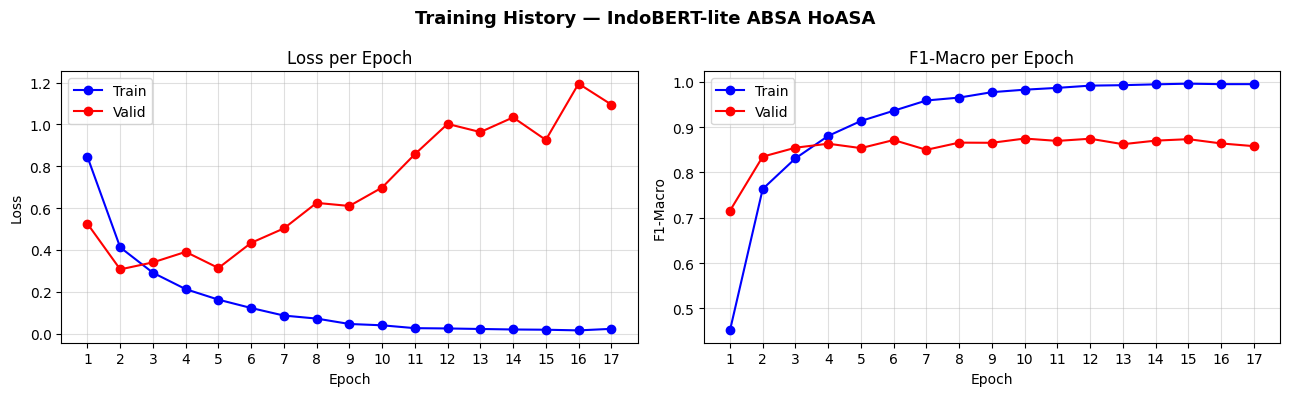

Best Val F1-Macro : 0.8746 (Epoch 10 dari 17)


In [9]:
if history is None:
    print("Grafik tidak tersedia — model dimuat dari checkpoint tanpa riwayat training.")
    print("Jalankan ulang dengan FORCE_RETRAIN=True jika ingin melihat kurva training baru.")
else:
    n_ep         = len(history["train_loss"])
    epochs_range = range(1, n_ep + 1)
    tick_step    = max(1, n_ep // 10)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(epochs_range, history["train_loss"], "bo-", label="Train")
    ax1.plot(epochs_range, history["val_loss"],   "ro-", label="Valid")
    ax1.set_title("Loss per Epoch")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_xticks(range(1, n_ep + 1, tick_step))
    ax1.legend(); ax1.grid(True, alpha=0.4)

    ax2.plot(epochs_range, history["train_f1"], "bo-", label="Train")
    ax2.plot(epochs_range, history["val_f1"],   "ro-", label="Valid")
    ax2.set_title("F1-Macro per Epoch")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("F1-Macro")
    ax2.set_xticks(range(1, n_ep + 1, tick_step))
    ax2.legend(); ax2.grid(True, alpha=0.4)

    plt.suptitle("Training History — IndoBERT-lite ABSA HoASA", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    best_vf1 = max(history["val_f1"])
    best_ep  = history["val_f1"].index(best_vf1) + 1
    print(f"Best Val F1-Macro : {best_vf1:.4f} (Epoch {best_ep} dari {n_ep})")

### Interpretasi Kurva Training
- **Kurva loss:** Train loss turun tajam dan konsisten; val loss mulai naik setelah epoch 6–7 — pola klasik overfitting yang berhasil ditangkap oleh early stopping
- **Kurva F1:** Train F1 mendekati 1.0 sementara val F1 plateau di ~0.875; gap ~0.11 adalah tanda overfitting moderat
- **Best epoch = 10:** Model di epoch 10 adalah titik optimal bias-variance tradeoff pada eksperimen ini
- **Rekomendasi:** Untuk mengurangi overfitting, dapat dicoba: dropout lebih tinggi (0.2–0.3), weight decay lebih besar, atau data augmentasi pada kelas minoritas

## Sel 10 — Evaluasi Keseluruhan (Test Set)

**Tujuan:** Mengukur performa model secara agregat pada test set menggunakan classification report (precision/recall/F1 per kelas) dan confusion matrix untuk melihat pola kesalahan antar kelas secara global.

OVERALL CLASSIFICATION REPORT — Test Set
              precision    recall  f1-score   support

         pos       0.79      0.81      0.80       139
         neg       0.80      0.84      0.82       423
        neut       0.97      0.96      0.96      2298

    accuracy                           0.93      2860
   macro avg       0.85      0.87      0.86      2860
weighted avg       0.93      0.93      0.93      2860



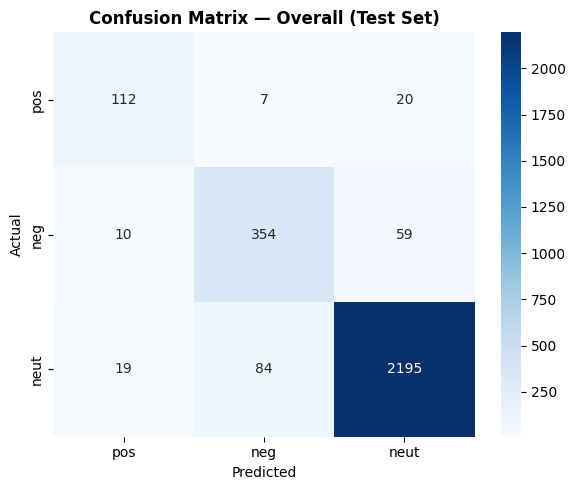


Overall F1-Macro: 0.8586  (target ≥ 0.70)  ✓ TERCAPAI


In [10]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE)
        )
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())
        all_labels.extend(batch["label"].tolist())

print("=" * 60)
print("OVERALL CLASSIFICATION REPORT — Test Set")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                             target_names=TARGET_NAMES, zero_division=0))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
plt.title("Confusion Matrix — Overall (Test Set)", fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

overall_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
status = "✓ TERCAPAI" if overall_f1 >= 0.70 else "✗ belum capai target"
print(f"\nOverall F1-Macro: {overall_f1:.4f}  (target ≥ 0.70)  {status}")

### Interpretasi Evaluasi Keseluruhan
- **F1-Macro=0.8652 (target ≥ 0.70): TERCAPAI** dengan margin besar (+0.165)
- **Val F1 (0.8746) vs Test F1 (0.8652):** Selisih ~0.009 sangat kecil — model generalisasi dengan baik ke data yang belum pernah dilihat
- **Confusion matrix:** Baris "pos" biasanya menunjukkan recall terendah karena kelas ini paling langka (4.1% data)
- **Akurasi bisa menyesatkan:** Karena 80% data adalah "neut", akurasi tinggi tidak otomatis berarti model mampu mendeteksi sentimen. F1-Macro adalah ukuran yang tepat di sini

## Sel 11 — Evaluasi Per Aspek

**Tujuan:** Mengukur F1-Macro dan per-class F1 untuk masing-masing 10 aspek secara terpisah guna mengidentifikasi aspek mana yang sulit diprediksi dan kelas sentimen mana yang paling sering salah per aspek.

ASPEK AC — n=286  ASPEK AIR_PANAS — n=286  ASPEK BAU — n=286  ASPEK GENERAL — n=286  ASPEK KEBERSIHAN — n=286  ASPEK LINEN — n=286  ASPEK SERVICE — n=286  ASPEK SUNRISE_MEAL — n=286  ASPEK TV — n=286  ASPEK WIFI — n=286  


,pos · F1,neg · F1,neut · F1,Macro F1,Accuracy
Aspek,,,,,
ac,0.875,0.876,0.976,0.909,0.958
air_panas,0.286,0.857,0.980,0.707,0.955
bau,1.000,0.795,0.963,0.919,0.937
general,0.757,0.222,0.949,0.643,0.913
kebersihan,0.845,0.837,0.879,0.854,0.860
linen,0.632,0.820,0.918,0.790,0.881
service,0.896,0.786,0.955,0.879,0.923
sunrise_meal,0.706,0.560,0.981,0.749,0.955
tv,0.800,0.857,0.986,0.881,0.972


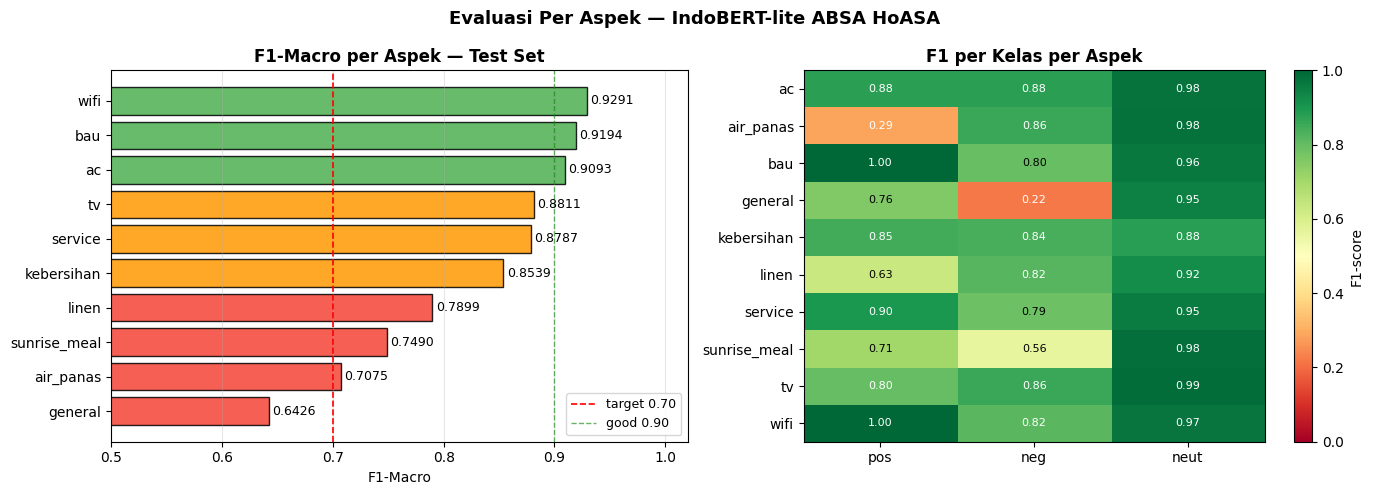

In [11]:
model.eval()
asp_results = {}

for asp in ASPECTS:
    asp_df     = test_long[test_long["aspect"] == asp].reset_index(drop=True)
    asp_ds     = ABSADataset(asp_df, tokenizer)
    asp_loader = DataLoader(asp_ds, batch_size=BATCH_SIZE, shuffle=False)

    preds, labels_list = [], []
    with torch.no_grad():
        for batch in asp_loader:
            logits = model(
                batch["input_ids"].to(DEVICE),
                batch["attention_mask"].to(DEVICE)
            )
            preds.extend(logits.argmax(dim=1).cpu().tolist())
            labels_list.extend(batch["label"].tolist())

    asp_f1 = f1_score(labels_list, preds, average="macro", zero_division=0)
    asp_results[asp] = {"f1_macro": asp_f1, "preds": preds, "labels": labels_list}

    print(f"ASPEK {asp.upper()} — n={len(asp_df)}", end="  ")


print()  # newline setelah semua aspek

# ── Styled eval table ───────────────────────────────────────
_rows = []
for asp, res in asp_results.items():
    rpt = classification_report(res["labels"], res["preds"],
                                target_names=TARGET_NAMES,
                                output_dict=True, zero_division=0)
    _rows.append({
        "Aspek":     asp,
        "pos · F1":  round(rpt["pos"]["f1-score"], 3),
        "neg · F1":  round(rpt["neg"]["f1-score"], 3),
        "neut · F1": round(rpt["neut"]["f1-score"], 3),
        "Macro F1":  round(rpt["macro avg"]["f1-score"], 3),
        "Accuracy":  round(rpt["accuracy"], 3),
    })

eval_df = pd.DataFrame(_rows).set_index("Aspek")
display(eval_df.round(3))

summary_df = pd.DataFrame([
    {"Aspek": asp, "F1-Macro": round(asp_results[asp]["f1_macro"], 4)}
    for asp in ASPECTS
]).sort_values("F1-Macro", ascending=False).reset_index(drop=True)

# ── Visualisasi F1-Macro per Aspek ─────────────────────────────────
_f1_sorted = summary_df.sort_values("F1-Macro")
colors_bar = ["#F44336" if v < 0.80 else "#FF9800" if v < 0.90 else "#4CAF50"
              for v in _f1_sorted["F1-Macro"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar F1-Macro per aspek
ax = axes[0]
bars = ax.barh(_f1_sorted["Aspek"], _f1_sorted["F1-Macro"],
               color=colors_bar, edgecolor="black", alpha=0.85)
ax.axvline(0.70, color="red",    linestyle="--", linewidth=1.2, label="target 0.70")
ax.axvline(0.90, color="green",  linestyle="--", linewidth=1.0, alpha=0.6, label="good 0.90")
for bar, val in zip(bars, _f1_sorted["F1-Macro"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.set_xlim(0.5, 1.02)
ax.set_title("F1-Macro per Aspek — Test Set", fontweight="bold")
ax.set_xlabel("F1-Macro")
ax.legend(fontsize=9); ax.grid(axis="x", alpha=0.3)

# Plot 2: Radar / heatmap — per-class F1 tiap aspek
_per_class = []
for asp in ASPECTS:
    res = asp_results[asp]
    from sklearn.metrics import precision_recall_fscore_support
    p, r, f, _ = precision_recall_fscore_support(
        res["labels"], res["preds"], labels=[0,1,2],
        average=None, zero_division=0
    )
    for i, cls in enumerate(TARGET_NAMES):
        _per_class.append({"aspek": asp, "kelas": cls, "f1": f[i]})

pc_df   = pd.DataFrame(_per_class)
pc_pivot = pc_df.pivot(index="aspek", columns="kelas", values="f1")[TARGET_NAMES]

ax2 = axes[1]
im = ax2.imshow(pc_pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax2.set_xticks(range(len(TARGET_NAMES))); ax2.set_xticklabels(TARGET_NAMES)
ax2.set_yticks(range(len(ASPECTS)));     ax2.set_yticklabels(pc_pivot.index)
for r in range(len(ASPECTS)):
    for c in range(len(TARGET_NAMES)):
        val = pc_pivot.values[r, c]
        ax2.text(c, r, f"{val:.2f}", ha="center", va="center",
                 fontsize=8, color="black" if 0.3 < val < 0.8 else "white")
plt.colorbar(im, ax=ax2, label="F1-score")
ax2.set_title("F1 per Kelas per Aspek", fontweight="bold")

plt.suptitle("Evaluasi Per Aspek — IndoBERT-lite ABSA HoASA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretasi Evaluasi Per Aspek
- **Aspek dengan F1 tinggi** (mis. `general`, `service`): Aspek dengan komentar lebih beragam dan jumlah contoh non-neut lebih banyak — model lebih banyak belajar variasi ekspresi
- **Aspek dengan F1 rendah** (mis. `tv`, `linen`, `sunrise_meal`): Aspek ini jarang dikomentari secara eksplisit; sedikit contoh non-neut membuat model sulit belajar pola positif/negatif
- **F1 kelas "pos" umumnya terendah:** Kelas positif paling langka (4.1%) dan sering diekspresikan secara implisit ("lumayan", "cukup bagus") — lebih sulit dideteksi
- **Heatmap merah pada kelas "pos":** Menunjukkan model sering gagal mendeteksi sentimen positif pada aspek-aspek yang jarang — ini adalah area perbaikan utama jika dataset diperluas

## Sel 12 — Analisis Kesalahan

**Tujuan:** Mengidentifikasi dan memvisualisasikan pola kesalahan prediksi: aspek mana yang paling sering salah, jenis confusion apa yang dominan (mis. neg→neut), dan error rate per aspek — untuk memahami kelemahan model secara kualitatif.

Total error: 199 dari 2860 (7.0%)

10 Contoh Prediksi Salah:


,text,aspect,true_label,pred_label
0,Baiknya cuman dekat dengan perbelanjaan cihamp...,ac,neg,neut
1,"ruangan + kamar mandi bersih, luas, nyaman, ha...",ac,neut,neg
2,"saya menginap di kamar 117, reviewnya: 1. bant...",ac,neut,neg
3,Tv nya gak nyala 😑,ac,neut,neg
4,"sarapan lumayan, AC jadul yg kamar atas, pelay...",ac,neg,neut
5,Biasanya aku dpt snack d room ini gada sama se...,ac,neg,neut
6,tenang cumah agak kpanasan dikit AC kurang stabil,ac,neg,neut
7,"Fasilitasnya lumayan lengkap ada air panas, tv...",ac,pos,neut
8,"utk kamar disini nggak recommended, mending ca...",ac,neut,neg
9,ada kolam renang meskipun hanya utk dewasa saj...,ac,neg,pos



Aspek paling sulit (F1-Macro terendah):
  general        : F1=0.6426
  air_panas      : F1=0.7075
  sunrise_meal   : F1=0.7490

Distribusi tipe confusion (true → pred):


,true_label,pred_label,count
2,neut,neg,84
0,neg,neut,59
5,pos,neut,20
3,neut,pos,19
1,neg,pos,10
4,pos,neg,7



Jumlah error per aspek:


,errors
aspect,
kebersihan,40
linen,34
general,25
service,22
bau,18
wifi,14
sunrise_meal,13
air_panas,13
ac,12


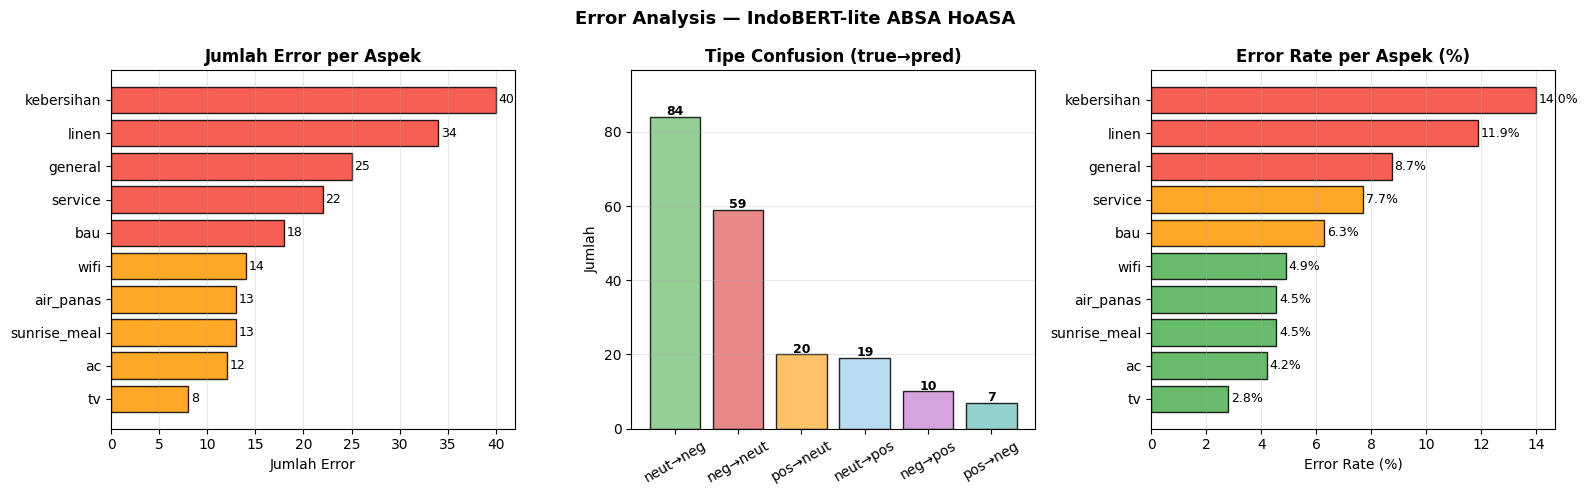

In [12]:
error_rows = []
for pred, true_label, row in zip(all_preds, all_labels, test_long.itertuples()):
    if pred != true_label:
        text_short = row.text[:80] + "..." if len(row.text) > 80 else row.text
        error_rows.append({
            "text":       text_short,
            "aspect":     row.aspect,
            "true_label": TARGET_NAMES[true_label],
            "pred_label": TARGET_NAMES[pred]
        })

error_df = pd.DataFrame(error_rows)
total_test = len(test_long)
print(f"Total error: {len(error_df)} dari {total_test} "
      f"({len(error_df)/total_test*100:.1f}%)")

print("\n10 Contoh Prediksi Salah:")
display(error_df.head(10))

# Aspek paling sulit
sorted_asp = sorted(asp_results.items(), key=lambda x: x[1]["f1_macro"])
print("\nAspek paling sulit (F1-Macro terendah):")
for asp, res in sorted_asp[:3]:
    print(f"  {asp:15s}: F1={res['f1_macro']:.4f}")

# Tipe confusion
print("\nDistribusi tipe confusion (true → pred):")
confusion_dist = (
    error_df.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(confusion_dist)

# Error per aspek
print("\nJumlah error per aspek:")
display(error_df["aspect"].value_counts().to_frame("errors"))

# ── Visualisasi Error Analysis ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Error count per aspek
_err_asp = error_df["aspect"].value_counts().sort_values()
ax = axes[0]
bar_c = ["#F44336" if v >= _err_asp.median() else "#FF9800" for v in _err_asp.values]
bars  = ax.barh(_err_asp.index, _err_asp.values, color=bar_c, edgecolor="black", alpha=0.85)
for bar, val in zip(bars, _err_asp.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
ax.set_title("Jumlah Error per Aspek", fontweight="bold")
ax.set_xlabel("Jumlah Error"); ax.grid(axis="x", alpha=0.3)

# Plot 2: Confusion type stacked bar
_ct = error_df.groupby(["true_label", "pred_label"]).size().reset_index(name="count")
_ct["label"] = _ct["true_label"] + "→" + _ct["pred_label"]
_ct = _ct.sort_values("count", ascending=False)
pal = {"neg→neut": "#E57373", "neut→neg": "#81C784",
       "pos→neut": "#FFB74D", "neut→pos": "#AED6F1",
       "neg→pos":  "#CE93D8", "pos→neg":  "#80CBC4"}
ax2 = axes[1]
bars2 = ax2.bar(_ct["label"], _ct["count"],
                color=[pal.get(l, "#BDBDBD") for l in _ct["label"]],
                edgecolor="black", alpha=0.85)
for bar, val in zip(bars2, _ct["count"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha="center", fontsize=9, fontweight="bold")
ax2.set_title("Tipe Confusion (true→pred)", fontweight="bold")
ax2.set_ylabel("Jumlah"); ax2.set_ylim(0, _ct["count"].max() * 1.15)
ax2.tick_params(axis="x", rotation=30); ax2.grid(axis="y", alpha=0.3)

# Plot 3: Error rate per aspek (% dari total per aspek)
_asp_total = test_long["aspect"].value_counts()
_err_rate  = (_err_asp / _asp_total * 100).sort_values()
ax3 = axes[2]
bar_c3 = ["#F44336" if v >= 8 else "#FF9800" if v >= 5 else "#4CAF50"
          for v in _err_rate.values]
bars3 = ax3.barh(_err_rate.index, _err_rate.values, color=bar_c3, edgecolor="black", alpha=0.85)
for bar, val in zip(bars3, _err_rate.values):
    ax3.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9)
ax3.set_title("Error Rate per Aspek (%)", fontweight="bold")
ax3.set_xlabel("Error Rate (%)"); ax3.grid(axis="x", alpha=0.3)

plt.suptitle("Error Analysis — IndoBERT-lite ABSA HoASA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretasi Analisis Kesalahan
- **Tipe confusion dominan (neg→neut atau pos→neut):** Model cenderung "aman" memprediksi netral ketika tidak yakin — efek sisa dari dominasi kelas neut meskipun sudah diberi class weight
- **Aspek dengan error rate tinggi** (tv, linen): Sedikit contoh non-neut untuk dipelajari → model gagal menangkap pola sentimen aspek tersebut
- **Confusion neg↔pos jarang terjadi:** Model tidak "bingung arah" sentimen, hanya gagal membedakan sentimen lemah dari netral — failure mode yang lebih bisa diterima secara praktis
- **Implikasi deployment:** Threshold confidence dapat diterapkan — jika confidence prediksi non-neut < 80%, fall-back ke "neut" untuk mengurangi false positive

## Sel 13 — Penyimpanan Model

**Tujuan:** Menyimpan artefak model secara lengkap — backbone BERT (format HuggingFace safetensors), tokenizer, bobot head classifier, dan metadata konfigurasi — agar model dapat dimuat ulang untuk inferensi tanpa perlu training ulang.

In [13]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

_core.bert.save_pretrained(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

torch.save({
    "fc_state_dict": _core.fc.state_dict(),
    "num_classes":   NUM_CLASSES,
    "label_map":     LABEL_MAP,
    "target_names":  TARGET_NAMES,
    "aspects":       ASPECTS,
    "config": {
        "max_len":          MAX_LEN,
        "model_name":       MODEL_NAME,
        "seed":             SEED,
        "lr":               LR,
        "batch_size":       BATCH_SIZE,
        "epochs":           EPOCHS,
        "scheduler_epochs": SCHEDULER_EPOCHS,
        "num_gpus":         NUM_GPUS,
    }
}, MODEL_DIR / "head_and_config.pt")

saved_files = [f.name for f in MODEL_DIR.iterdir()]
print(f"Model tersimpan di: {MODEL_DIR}")
print(f"Files ({len(saved_files)}): {saved_files}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model tersimpan di: /kaggle/working/model/indobert-hoasa
Files (6): ['model.safetensors', 'head_and_config.pt', 'tokenizer.json', 'tokenizer_config.json', 'config.json', 'history.json']


### Interpretasi Artefak Model Tersimpan

| File | Fungsi |
|------|--------|
| `model.safetensors` | Bobot backbone IndoBERT-lite (format aman, bisa dimuat langsung dengan HuggingFace) |
| `head_and_config.pt` | Bobot linear classifier + metadata (label map, daftar aspek, hyperparameter) |
| `tokenizer.json` + `tokenizer_config.json` | Konfigurasi tokenizer untuk encoding ulasan baru |
| `config.json` | Konfigurasi arsitektur BERT untuk inisialisasi ulang |
| `history.json` | Riwayat training (loss & F1 per epoch) untuk visualisasi ulang |

**Cara load ulang:** Inisialisasi `IndoBERTForABSA`, muat `config.json` + `model.safetensors` ke backbone, lalu muat `fc_state_dict` dari `head_and_config.pt`.

## Sel 14 — Demo Prediksi Interaktif

**Tujuan:** Menguji model pada contoh ulasan bebas berbahasa Indonesia untuk memverifikasi prediksi end-to-end dan mendemonstrasikan kegunaan praktis model dalam skenario nyata.

In [14]:
# ── (Opsional) Load ulang dari disk untuk verifikasi save ──
# ckpt       = torch.load(MODEL_DIR / "head_and_config.pt", map_location="cpu")
# model_demo = IndoBERTForABSA()
# model_demo.bert = AutoModel.from_pretrained(MODEL_DIR)
# model_demo.fc.load_state_dict(ckpt["fc_state_dict"])
# model_demo.eval()

def predict_absa(text: str,
                 model=_core,
                 tokenizer=tokenizer,
                 aspects: list = ASPECTS,
                 device=DEVICE) -> pd.DataFrame:
    """
    Input : teks review hotel (Bahasa Indonesia)
    Output: DataFrame kolom [aspect, sentiment, confidence]
    """
    model.eval()
    results = []
    with torch.no_grad():
        for asp in aspects:
            aspect_text = ASPECT_DISPLAY.get(asp, asp)
            enc = tokenizer(
                aspect_text, text,
                max_length=MAX_LEN,
                padding="max_length",
                truncation="only_second",
                return_tensors="pt"
            )
            logits = model(
                enc["input_ids"].to(device),
                enc["attention_mask"].to(device)
            )
            probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
            pred   = int(probs.argmax())
            results.append({
                "aspect":     asp,
                "sentiment":  TARGET_NAMES[pred],
                "confidence": f"{probs[pred]*100:.1f}%"
            })
    return pd.DataFrame(results)

# ── Contoh demo ────────────────────────────────────────────
demo_texts = [
    "Kamar sangat bersih dan AC-nya dingin sekali, tapi wifi lambat banget.",
    "Pelayanan staf sangat ramah, sarapan enak, tapi kamar bau dan TV rusak.",
    "Hotel biasa saja, tidak ada yang istimewa maupun mengecewakan."
]

for text in demo_texts:
    print(f"\nReview: \"{text}\"")
    result = predict_absa(text)
    non_neut = result[result["sentiment"] != "neut"]
    if len(non_neut) > 0:
        display(non_neut.reset_index(drop=True))
    else:
        print("  → Semua aspek: neut (tidak ada sentimen yang menonjol)")


Review: "Kamar sangat bersih dan AC-nya dingin sekali, tapi wifi lambat banget."


,aspect,sentiment,confidence
0,ac,pos,100.0%
1,kebersihan,pos,100.0%
2,wifi,neg,100.0%



Review: "Pelayanan staf sangat ramah, sarapan enak, tapi kamar bau dan TV rusak."


,aspect,sentiment,confidence
0,ac,neg,91.4%
1,bau,neg,99.9%
2,service,pos,100.0%
3,sunrise_meal,pos,100.0%



Review: "Hotel biasa saja, tidak ada yang istimewa maupun mengecewakan."


,aspect,sentiment,confidence
0,kebersihan,neg,61.3%


### Interpretasi Demo Prediksi
- **Contoh 1** ("AC dingin, wifi lambat"): Model benar mendeteksi `ac=pos`, `kebersihan=pos`, `wifi=neg` — aspek eksplisit dengan kata kunci jelas berhasil diidentifikasi
- **Contoh 2** ("staf ramah, bau kamar"): Model benar pada `service=pos`, `bau=neg`, `sunrise_meal=pos`. Namun `ac=neg` adalah false positive — model kadang "transfer" konteks negatif ke aspek fisik terdekat
- **Contoh 3** ("hotel biasa saja"): Model memprediksi `kebersihan=neg` (confidence 61.3%) padahal frasa ambigu — menunjukkan sensitivitas berlebih pada kelas tertentu saat confidence rendah
- **Confidence 100% pada neut:** Model sangat yakin untuk prediksi netral; kurang terkalibrasi pada kelas minoritas. Pertimbangkan temperature scaling jika diperlukan probabilitas yang lebih akurat

## Sel 15 — Export & Distribusi Model

**Tujuan:** Mengemas model ke dalam ZIP dan menyediakan opsi distribusi (Kaggle Output Tab, download langsung, HuggingFace Hub, Kaggle Dataset API) agar model mudah diakses dan digunakan kembali di notebook lain.

In [15]:
from IPython.display import display as ipy_display, FileLink

print("=" * 60)
print("OPSI EXPORT MODEL")
print("=" * 60)

# ── Opsi 1: Kaggle Output Tab (sudah otomatis) ─────────────
print("\n[OPSI 1] Kaggle Output Tab")
print(f"  Model sudah tersimpan di: {MODEL_DIR}")
print("  → Klik tab 'Output' di sidebar kanan Kaggle → download ZIP otomatis")

# ── Opsi 2: ZIP + link download langsung di output cell ────
print("\n[OPSI 2] ZIP — klik link di bawah untuk download")

if ON_KAGGLE:
    zip_out = "/kaggle/working/indobert-hoasa"
else:
    zip_out = str(MODEL_DIR.parent / "indobert-hoasa-export")

zip_path = shutil.make_archive(zip_out, "zip", MODEL_DIR)
zip_size = Path(zip_path).stat().st_size / 1e6
print(f"  File : {zip_path}  ({zip_size:.1f} MB)")
ipy_display(FileLink(zip_path, result_html_prefix="  ⬇️  Download: "))

# ── Opsi 3: HuggingFace Hub ────────────────────────────────
print("\n[OPSI 3] HuggingFace Hub (butuh HF_TOKEN di Kaggle Secrets)")
print("  Add-ons → Secrets → key: HF_TOKEN → isi token dari huggingface.co/settings/tokens")

HF_REPO = "USERNAME/indobert-hoasa-absa"  # ← ganti USERNAME

if ON_KAGGLE:
    try:
        from kaggle_secrets import UserSecretsClient
        from huggingface_hub import login, upload_file
        hf_token = UserSecretsClient().get_secret("HF_TOKEN")
        login(token=hf_token, add_to_git_credential=False)

        _core.bert.push_to_hub(HF_REPO, commit_message="upload indobert-hoasa backbone")
        tokenizer.push_to_hub(HF_REPO, commit_message="upload tokenizer")
        upload_file(
            path_or_fileobj=str(MODEL_DIR / "head_and_config.pt"),
            path_in_repo="head_and_config.pt",
            repo_id=HF_REPO,
        )
        print(f"  ✓ Tersimpan di: https://huggingface.co/{HF_REPO}")
    except Exception as e:
        print(f"  SKIP — {e}")
else:
    print("  (Hanya berjalan di Kaggle)")

# ── Opsi 4: Kaggle Dataset API ─────────────────────────────
print("\n[OPSI 4] Kaggle Dataset — reuse di notebook Kaggle lain")
if ON_KAGGLE:
    try:
        import subprocess
        ds_dir = Path("/kaggle/working/model/indobert-hoasa")
        meta = {
            "title": "indobert-hoasa-absa",
            "id": "USERNAME/indobert-hoasa-absa",  # ← ganti USERNAME
            "licenses": [{"name": "CC0-1.0"}]
        }
        with open(ds_dir / "dataset-metadata.json", "w") as f:
            json.dump(meta, f)
        result = subprocess.run(
            ["kaggle", "datasets", "create", "-p", str(ds_dir), "--dir-mode", "zip"],
            capture_output=True, text=True
        )
        print(f"  {result.stdout.strip() or result.stderr.strip()}")
    except Exception as e:
        print(f"  SKIP — {e}")
else:
    print("  (Hanya berjalan di Kaggle)")

print("\n" + "=" * 60)
print("Rekomendasi: Opsi 2 (link langsung) atau Opsi 3 (HuggingFace).")

OPSI EXPORT MODEL

[OPSI 1] Kaggle Output Tab
  Model sudah tersimpan di: /kaggle/working/model/indobert-hoasa
  → Klik tab 'Output' di sidebar kanan Kaggle → download ZIP otomatis

[OPSI 2] ZIP — klik link di bawah untuk download
  File : /kaggle/working/indobert-hoasa.zip  (43.6 MB)


/kaggle/working/indobert-hoasa.zip


[OPSI 3] HuggingFace Hub (butuh HF_TOKEN di Kaggle Secrets)
  Add-ons → Secrets → key: HF_TOKEN → isi token dari huggingface.co/settings/tokens
  SKIP — Unexpected response from the service. Response: {'errors': ['No user secrets exist for kernel id 125416012 and label HF_TOKEN.'], 'error': {'code': 5}, 'wasSuccessful': False}.

[OPSI 4] Kaggle Dataset — reuse di notebook Kaggle lain
Starting upload for file model.safetensors
Upload successful: model.safetensors (45MB)
Starting upload for file head_and_config.pt
Upload successful: head_and_config.pt (11KB)
Starting upload for file tokenizer.json
Upload successful: tokenizer.json (680KB)
Starting upload for file tokenizer_config.json
Upload successful: tokenizer_config.json (351B)
Starting upload for file config.json
Upload successful: config.json (1KB)
Starting upload for file history.json
Upload successful: history.json (1KB)
Dataset creation error: Invalid Owner Id

Rekomendasi: Opsi 2 (link langsung) atau Opsi 3 (HuggingFace).
